In [2]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
inte_df = pd.read_csv("world_development_data_interpolated.csv")
print(inte_df.shape)

(9947, 33)


In [4]:
impu_df = pd.read_csv("world_development_data_imputed.csv")
print(impu_df.shape)

(4444, 26)


In [5]:
inte_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9947 entries, 0 to 9946
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year                 9947 non-null   int64  
 1   Country              9947 non-null   object 
 2   Region               9947 non-null   object 
 3   SubRegion            9947 non-null   object 
 4   IntermRegion         4214 non-null   object 
 5   SurfAreaSqKm         9900 non-null   float64
 6   PopDens              9297 non-null   float64
 7   PopGrowth%           9929 non-null   float64
 8   GDP                  8668 non-null   float64
 9   GDPGrowth%           8424 non-null   float64
 10  AdolFertRate         9947 non-null   float64
 11  AgriValAdd%GDP       7496 non-null   float64
 12  DomCredit%GDP        1185 non-null   float64
 13  Exports%GDP          7434 non-null   float64
 14  FertRate             9746 non-null   float64
 15  FDINetBoP            8557 non-null   f

In [6]:
impu_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4444 entries, 0 to 4443
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             4444 non-null   float64
 1   Country          4444 non-null   object 
 2   Region           4444 non-null   object 
 3   SubRegion        4444 non-null   object 
 4   SurfAreaSqKm     4444 non-null   float64
 5   PopTotal         4444 non-null   float64
 6   PopDens          4444 non-null   float64
 7   PopGrowth%       4444 non-null   float64
 8   GDP              4444 non-null   float64
 9   GDPGrowth%       4444 non-null   float64
 10  AdolFertRate     4444 non-null   float64
 11  AgriValAdd%GDP   4444 non-null   float64
 12  Exports%GDP      4444 non-null   float64
 13  FertRate         4444 non-null   float64
 14  FDINetBoP        4444 non-null   float64
 15  GNI/CapAtlas     4444 non-null   float64
 16  GNIAtlas         4444 non-null   float64
 17  Imports%GDP   

In [7]:
# This code take one random example and print it type
print(f"All data type in column \'Country\': {set(inte_df['Country'].map(type))}")
print(f"All data type in column \'Region\': {set(inte_df['Region'].map(type))}")
print(f"All data type in column \'SubRegion\': {set(inte_df['SubRegion'].map(type))}")
print(f"All data type in column \'IntermRegion\': {set(inte_df['IntermRegion'].map(type))}")

All data type in column 'Country': {<class 'str'>}
All data type in column 'Region': {<class 'str'>}
All data type in column 'SubRegion': {<class 'str'>}
All data type in column 'IntermRegion': {<class 'float'>, <class 'str'>}


In [8]:
# All unique values in 'Country', 'Region', 'SubRegion', and 'IntermRegion' columns
def pie_chart(df, col_name):
    # Contoh data
    value_counts = df[col_name].value_counts()

    # Jika jumlah nilai unik kurang dari atau sama dengan 5, tidak perlu menambahkan 'Other'
    if len(value_counts) <= 5:
        combined = value_counts
    else:
        # Mengambil lima nilai teratas
        top5 = value_counts.head(5)

        # Menggabungkan sisanya menjadi kategori 'other'
        other = pd.Series(value_counts.iloc[5:].sum(), index=['Other'])

        # Menggabungkan top5 dan 'other' menggunakan pd.concat
        combined = pd.concat([top5, other])

    # Membuat pie chart
    plt.figure(figsize=(4, 4))
    plt.pie(combined, labels=combined.index, autopct='%1.1f%%', startangle=90)
    plt.title(f'Percentage of unique values in \'{col_name}\' column')
    plt.show()

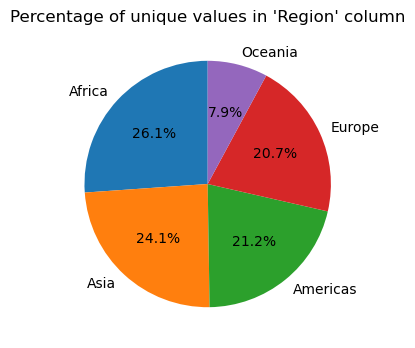

In [9]:
pie_chart(inte_df, 'Region')

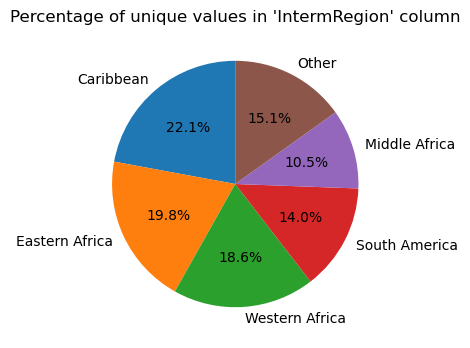

In [10]:
pie_chart(inte_df, 'IntermRegion')

In [11]:
# Check Missing Values
print(f"Total missing values in interpolated_data: {inte_df.isna().sum().sum()}")

Total missing values in interpolated_data: 58503


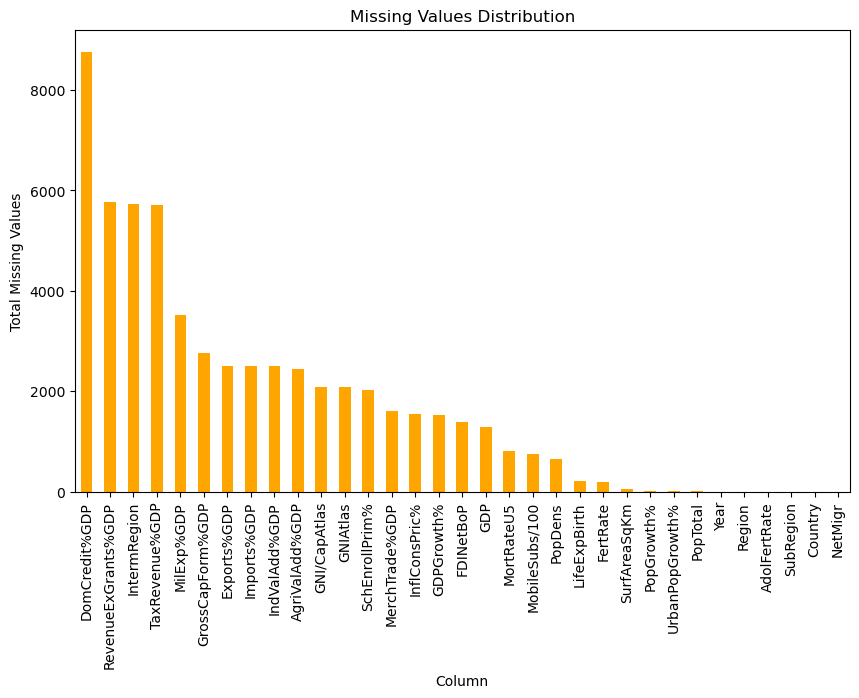

In [12]:
nan_counts_inte_df = inte_df.isnull().sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
nan_counts_inte_df.plot(kind='bar', color='orange', grid=False)
plt.title('Missing Values Distribution')
plt.xlabel('Column')
plt.ylabel('Total Missing Values')
plt.xticks(rotation=90)
plt.show()

In [13]:
print(f"Total missing values in imputed_data: {impu_df.isna().sum().sum()}")

Total missing values in imputed_data: 0


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the imputed dataset
df = pd.read_csv("world_development_data_imputed.csv")

# Check structure
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

# Convert year to integer
df["Year"] = df["Year"].astype(int)

# Sort data
df = df.sort_values(["Country", "Year"])

# Basic information
display(df.head())
display(df.describe().T)

Dataset shape: (4444, 26)

Columns:
['Year', 'Country', 'Region', 'SubRegion', 'SurfAreaSqKm', 'PopTotal', 'PopDens', 'PopGrowth%', 'GDP', 'GDPGrowth%', 'AdolFertRate', 'AgriValAdd%GDP', 'Exports%GDP', 'FertRate', 'FDINetBoP', 'GNI/CapAtlas', 'GNIAtlas', 'Imports%GDP', 'IndValAdd%GDP', 'InflConsPric%', 'LifeExpBirth', 'MerchTrade%GDP', 'MobileSubs/100', 'MortRateU5', 'NetMigr', 'UrbanPopGrowth%']


,Year,Country,Region,SubRegion,SurfAreaSqKm,PopTotal,PopDens,PopGrowth%,GDP,GDPGrowth%,...,GNIAtlas,Imports%GDP,IndValAdd%GDP,InflConsPric%,LifeExpBirth,MerchTrade%GDP,MobileSubs/100,MortRateU5,NetMigr,UrbanPopGrowth%
0,2000,Afghanistan,Asia,Southern Asia,652860.0,19542982.0,29.963329,1.443803,1.801248e+10,-5.206288,...,1.778669e+10,41.312634,17.178775,37.611028,55.298,52.777048,0.000000,129.3,-1007135.0,1.861377
399,2001,Afghanistan,Asia,Southern Asia,652860.0,19688632.0,30.186640,0.742517,1.672635e+10,-1.972096,...,1.465537e+10,41.069212,17.289137,29.448630,55.798,52.601586,0.000000,125.3,-192286.0,1.153839
431,2002,Afghanistan,Asia,Southern Asia,652860.0,21000256.0,32.197624,6.449321,3.854235e+09,0.565165,...,3.601346e+09,64.268859,23.810127,215.539767,56.454,66.212876,0.119046,121.2,1327074.0,6.863453
791,2003,Afghanistan,Asia,Southern Asia,652860.0,22645130.0,34.719547,7.541019,4.539497e+09,8.832278,...,4.283569e+09,65.121547,22.710864,11.655238,57.344,49.454823,0.883192,117.0,388632.0,7.953448
987,2004,Afghanistan,Asia,Southern Asia,652860.0,23553551.0,36.112339,3.933178,5.220825e+09,1.414118,...,5.018562e+09,54.095155,26.226790,11.271432,57.944,47.540379,2.547387,112.8,-248616.0,4.588653


,count,mean,std,min,25%,50%,75%,max
Year,4444.0,2.010500e+03,6.345003e+00,2.000000e+03,2.005000e+03,2.010500e+03,2.016000e+03,2.021000e+03
SurfAreaSqKm,4444.0,6.640703e+05,1.888320e+06,2.000000e+01,1.782000e+04,1.113700e+05,5.053700e+05,1.709825e+07
PopTotal,4444.0,3.445608e+07,1.331737e+08,9.609000e+03,1.231632e+06,6.469593e+06,2.230908e+07,1.412360e+09
PopDens,4444.0,3.128790e+02,1.501366e+03,1.364917e-01,3.130881e+01,7.932052e+01,1.843498e+02,2.159480e+04
PopGrowth%,4444.0,1.374862e+00,1.542070e+00,-6.852118e+00,4.251318e-01,1.255840e+00,2.267222e+00,1.936043e+01
GDP,4444.0,3.194480e+11,1.411696e+12,1.396473e+07,4.558559e+09,1.977252e+10,1.288408e+11,2.331508e+13
GDPGrowth%,4444.0,3.268364e+00,5.749729e+00,-5.423590e+01,1.099784e+00,3.494868e+00,5.857273e+00,8.682675e+01
AdolFertRate,4444.0,5.346941e+01,4.348099e+01,1.493000e+00,1.722575e+01,4.159900e+01,7.774200e+01,2.053850e+02
AgriValAdd%GDP,4444.0,1.096285e+01,1.119533e+01,1.251885e-02,2.088816e+00,6.979923e+00,1.719215e+01,7.904236e+01
Exports%GDP,4444.0,4.426378e+01,2.912412e+01,2.249870e+00,2.462299e+01,3.853097e+01,6.079624e+01,2.289938e+02


In [15]:
# Load the imputed dataset
df = pd.read_csv("world_development_data_interpolated.csv")

# Check structure
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

# Convert year to integer
df["Year"] = df["Year"].astype(int)

# Sort data
df = df.sort_values(["Country", "Year"])

# Basic information
display(df.head())
display(df.describe().T)



Dataset shape: (9947, 33)

Columns:
['Year', 'Country', 'Region', 'SubRegion', 'IntermRegion', 'SurfAreaSqKm', 'PopDens', 'PopGrowth%', 'GDP', 'GDPGrowth%', 'AdolFertRate', 'AgriValAdd%GDP', 'DomCredit%GDP', 'Exports%GDP', 'FertRate', 'FDINetBoP', 'GNI/CapAtlas', 'GNIAtlas', 'GrossCapForm%GDP', 'Imports%GDP', 'IndValAdd%GDP', 'InflConsPric%', 'LifeExpBirth', 'MerchTrade%GDP', 'MilExp%GDP', 'MobileSubs/100', 'MortRateU5', 'NetMigr', 'PopTotal', 'RevenueExGrants%GDP', 'SchEnrollPrim%', 'TaxRevenue%GDP', 'UrbanPopGrowth%']


,Year,Country,Region,SubRegion,IntermRegion,SurfAreaSqKm,PopDens,PopGrowth%,GDP,GDPGrowth%,...,MerchTrade%GDP,MilExp%GDP,MobileSubs/100,MortRateU5,NetMigr,PopTotal,RevenueExGrants%GDP,SchEnrollPrim%,TaxRevenue%GDP,UrbanPopGrowth%
0,1973,Afghanistan,Asia,Southern Asia,NaN,652860.0,17.747275,2.524421,1.733333e+09,NaN,...,18.173078,1.868910,NaN,285.2,-3030.0,11575305.0,NaN,35.214371,NaN,5.688982
229,1974,Afghanistan,Asia,Southern Asia,NaN,652860.0,18.198916,2.513007,2.155555e+09,NaN,...,21.943300,1.610825,NaN,279.6,-20009.0,11869879.0,NaN,35.760830,NaN,5.663689
593,1975,Afghanistan,Asia,Southern Asia,NaN,652860.0,18.639722,2.393287,2.366667e+09,NaN,...,23.957747,1.722066,0.0,274.0,-44418.0,12157386.0,NaN,36.715912,NaN,5.535783
800,1976,Afghanistan,Asia,Southern Asia,NaN,652860.0,19.050438,2.179517,2.555556e+09,NaN,...,21.600000,2.046087,0.0,268.3,-85430.0,12425267.0,NaN,37.601509,NaN,5.304430
981,1977,Afghanistan,Asia,Southern Asia,NaN,652860.0,19.452189,2.086951,2.953333e+09,NaN,...,21.467268,2.011475,0.0,262.4,-83115.0,12687301.0,NaN,38.380409,NaN,5.186054


,count,mean,std,min,25%,50%,75%,max
Year,9947.0,1.997000e+03,1.414285e+01,1.973000e+03,1.985000e+03,1.997000e+03,2.009000e+03,2.021000e+03
SurfAreaSqKm,9900.0,6.630547e+05,1.882568e+06,2.000000e+01,1.782000e+04,1.109950e+05,4.881000e+05,1.709825e+07
PopDens,9297.0,2.805437e+02,1.399257e+03,1.364356e-01,2.199005e+01,6.680472e+01,1.546331e+02,2.159480e+04
PopGrowth%,9929.0,1.644351e+00,1.685601e+00,-2.772222e+01,5.928608e-01,1.579620e+00,2.586997e+00,1.936043e+01
GDP,8668.0,2.169398e+11,1.080045e+12,8.824746e+06,2.258169e+09,1.130180e+10,7.006243e+10,2.331508e+13
GDPGrowth%,8424.0,3.431273e+00,6.312911e+00,-6.404711e+01,1.089462e+00,3.636124e+00,6.058192e+00,1.499730e+02
AdolFertRate,9947.0,6.804446e+01,4.997650e+01,1.493000e+00,2.668600e+01,5.674200e+01,9.884750e+01,2.364890e+02
AgriValAdd%GDP,7496.0,1.454061e+01,1.322297e+01,1.251885e-02,3.701222e+00,1.038238e+01,2.271753e+01,7.904236e+01
DomCredit%GDP,1185.0,7.490132e+01,6.471951e+01,-9.313642e+00,3.290897e+01,5.550176e+01,9.021376e+01,3.910831e+02
Exports%GDP,7434.0,3.758169e+01,2.783530e+01,5.376759e-03,1.960582e+01,3.052253e+01,4.767359e+01,2.289938e+02


In [16]:
kpis = [
    "GDP",
    "GDPGrowth%",
    "GNI/CapAtlas",
    "LifeExpBirth",
    "MortRateU5",
    "FertRate",
    "MobileSubs/100",
    "AgriValAdd%GDP",
    "Exports%GDP",
    "Imports%GDP",
    "PopGrowth%"
]
kpis = [x for x in kpis if x in df.columns]
kpi_results = []

for indicator in kpis:
    start = df.loc[df["Year"] == 2000, indicator].median()
    end = df.loc[df["Year"] == 2021, indicator].median()

    change = end - start
    if start != 0:
        percentage_change = (change / abs(start)) * 100
    else:
        percentage_change = np.nan

    direction = "Increase" if change > 0 else "Decrease" if change < 0 else "No change"

kpi_results.append({
     "Indicator": indicator,
        "2000": start,
        "2021": end,
        "Absolute Change": change,
        "% Change": percentage_change,
        "Direction": direction
})  
kpi_table = pd.DataFrame(kpi_results)

display(kpi_table.round(2))    

,Indicator,2000,2021,Absolute Change,% Change,Direction
0,PopGrowth%,1.44,0.92,-0.52,-36.22,Decrease


In [17]:
# Find the countries with the largest improvements
def country_change(indicator, start_year=2000, end_year=2021):
    start = df[df["Year"] == start_year][["Country", indicator]]
    end = df[df["Year"] == end_year][["Country", indicator]]

    merged = start.merge(
        end,
        on="Country",
        suffixies=("start", "end")
    )
    merged["Absolute Change"] = (
        merged[f"{indicator}_end"] - 
        merged[f"{indicator}_start"]
    )
    merged["% Changed"] = (
        merged["Absolute Change"] / 
        merged[f"{indicator}_start"].abs()
    ) * 100
    return merged.sort_values("Absolute Change", ascending=False)

In [18]:
# Find the countries with the largest improvements
def country_change(indicator, start_year=2000, end_year=2021):

    start = df[df["Year"] == start_year][["Country", indicator]]
    end =  df[df["Year"] == end_year][["Country", indicator]]

    merged = start.merge(
        end,
        on="Country",
        suffixes=("_start", "_end")
    )
    merged["Absolute Change"] = (
        merged[f"{indicator}_end"] - 
        merged[f"{indicator}_start"]
    )
    merged["% Change"] = (
        merged["Absolute Change"] /
        merged[f"{indicator}_start"].abs()
    ) * 100
    return merged.sort_values("Absolute Change", ascending=False)

# Example: life expectancy
life_expectancy_change = country_change("LifeExpBirth")

print("Countries with largest increase in life expectancy:")
display(life_expectancy_change.head(10))

print("Countries with largest decrease in life expectancy:")
display(life_expectancy_change.tail(10))

Countries with largest increase in life expectancy:


,Country,LifeExpBirth_start,LifeExpBirth_end,Absolute Change,% Change
153,Rwanda,47.129,66.072,18.943,40.193936
112,Malawi,44.518,62.904,18.386,41.300148
201,Zambia,45.231,61.223,15.992,35.356282
4,Angola,46.024,61.643,15.619,33.936642
160,Sierra Leone,45.050,60.062,15.012,33.322974
202,Zimbabwe,44.686,59.253,14.567,32.598577
62,Ethiopia,50.538,64.975,14.437,28.566623
189,Uganda,48.342,62.705,14.363,29.711224
30,Burundi,47.514,61.663,14.149,29.778592
178,Tanzania,52.362,66.201,13.839,26.429472


Countries with largest decrease in life expectancy:


,Country,LifeExpBirth_start,LifeExpBirth_end,Absolute Change,% Change
44,Costa Rica,77.586000,77.023,-0.563,-0.725646
139,Oman,73.466000,72.541,-0.925,-1.259086
171,St. Vincent and the Grenadines,71.377000,69.629,-1.748,-2.448968
197,"Venezuela, RB",72.478000,70.554,-1.924,-2.654599
47,Cuba,76.183000,73.683,-2.500,-3.281572
120,Mexico,73.569000,70.213,-3.356,-4.561704
3,Andorra,NaN,NaN,NaN,NaN
35,Cayman Islands,NaN,NaN,NaN,NaN
48,Curacao,73.033951,NaN,NaN,NaN
141,Palau,70.493659,NaN,NaN,NaN


In [19]:
# Analyse under-five mortality improvement
mortality_change = country_change("MortRateU5")

print("Largest reductions in under-five mortality:")
display(
    mortality_change
    .sort_values("Absolute Change")
    .head(10)
)

Largest reductions in under-five mortality:


,Country,MortRateU5_start,MortRateU5_end,Absolute Change,% Change
153,Rwanda,185.4,39.4,-146.0,-78.748652
4,Angola,205.1,69.4,-135.7,-66.162847
112,Malawi,174.2,41.9,-132.3,-75.947187
160,Sierra Leone,225.9,104.7,-121.2,-53.652058
135,Niger,228.5,115.2,-113.3,-49.584245
105,Liberia,189.2,76.0,-113.2,-59.830867
189,Uganda,146.1,42.1,-104.0,-71.184120
30,Burundi,154.6,52.6,-102.0,-65.976714
126,Mozambique,170.7,69.6,-101.1,-59.226714
78,Guinea-Bissau,174.5,74.3,-100.2,-57.421203


In [20]:
mortality_change["Mortality Reduction %"] = (
    -mortality_change["% Change"]
)
display(
    mortality_change[
         ["Country", "Absolute Change", "Mortality Reduction %"]
    ]
    .sort_values("Mortality Reduction %", ascending=False)
    .head(10)
)

,Country,Absolute Change,Mortality Reduction %
114,Maldives,-33.1,84.654731
124,Montenegro,-11.9,83.802817
60,Estonia,-9.0,81.818182
155,Sao Tome and Principe,-67.0,81.310680
39,China,-29.8,81.198910
16,Belarus,-10.1,78.906250
153,Rwanda,-146.0,78.748652
123,Mongolia,-48.9,76.886792
195,Uzbekistan,-46.4,76.694215
32,Cambodia,-81.5,76.669802


In [21]:
# Regional KPI analysis
regional_kpis = df.groupby(
    ["Region", "Year"]
)[
    [
        "LifeExpBirth",
        "MortRateU5",
        "FertRate",
        "GDPGrowth%",
        "GNI/CapAtlas",
        "MobileSubs/100",
        "AgriValAdd%GDP"
    
]
    ].median().reset_index()
display(regional_kpis.head())

,Region,Year,LifeExpBirth,MortRateU5,FertRate,GDPGrowth%,GNI/CapAtlas,MobileSubs/100,AgriValAdd%GDP
0,Africa,1973,46.8675,207.9,6.7965,3.506830,220.0,NaN,30.921364
1,Africa,1974,47.4900,203.8,6.8090,5.878794,290.0,NaN,31.061883
2,Africa,1975,48.1295,201.7,6.7705,3.177405,320.0,0.0,29.976185
3,Africa,1976,48.8795,194.1,6.7430,6.220975,345.0,0.0,29.348364
4,Africa,1977,49.4740,187.8,6.7680,3.622905,360.0,0.0,30.150585


In [22]:
regional_change = []

for region in df["Region"].dropna().unique():

    region_data = regional_kpis[
        regional_kpis["Region"] == region 
    ]
    for indicator in[
        "LifeExpBirth",
        "MortRateU5",
        "FertRate",
        "GNI/CapAtlas",
        "MobileSubs/100"
    ]:
        start = region_data.loc[
            region_data["Year"] == 2000, indicator
        ].iloc[0]
        
        end = region_data.loc[
            region_data["Year"] == 2021, indicator
        ].iloc[0]

        regional_change.append({
             "Region": region,
            "Indicator": indicator,
            "2000": start,
            "2021": end,
            "Change": end - start,
            "% Change": ((end - start) / abs(start)) * 100
        })
regional_change_df = pd.DataFrame(regional_change)

display(regional_change_df.round(2))

,Region,Indicator,2000,2021,Change,% Change
0,Asia,LifeExpBirth,70.39,72.54,2.15,3.06
1,Asia,MortRateU5,36.80,14.10,-22.70,-61.68
2,Asia,FertRate,2.74,2.08,-0.66,-23.97
3,Asia,GNI/CapAtlas,1395.00,4775.00,3380.00,242.29
4,Asia,MobileSubs/100,3.63,128.96,125.33,3448.02
5,Europe,LifeExpBirth,76.31,80.70,4.39,5.75
6,Europe,MortRateU5,7.40,3.70,-3.70,-50.00
7,Europe,FertRate,1.48,1.57,0.09,6.08
8,Europe,GNI/CapAtlas,11110.00,25495.00,14385.00,129.48
9,Europe,MobileSubs/100,41.17,122.90,81.73,198.52


In [23]:
# Calculate yearly global development trends
yearly = df.groupby("Year").agg({
    "LifeExpBirth": "median",
    "MortRateU5": "median",
    "FertRate": "median",
    "GNI/CapAtlas": "median",
    "MobileSubs/100": "median",
    "AgriValAdd%GDP": "median",
    "GDPGrowth%": "median"
})
display(yearly)

,LifeExpBirth,MortRateU5,FertRate,GNI/CapAtlas,MobileSubs/100,AgriValAdd%GDP,GDPGrowth%
Year,,,,,,,
1973,60.859500,85.70,5.3770,520.0,NaN,24.606951,5.392760
1974,61.524976,82.30,5.2510,740.0,NaN,24.277073,4.961853
1975,61.790610,80.05,5.0730,865.0,0.000000,23.470835,2.440541
1976,62.060000,78.05,4.9550,810.0,0.000000,20.899106,5.517564
1977,62.538000,75.30,4.8420,920.0,0.000000,21.405857,4.918031
1978,63.352000,76.35,4.7150,1010.0,0.000000,19.916913,5.322766
1979,63.506500,73.60,4.6190,1280.0,0.000000,18.518872,4.514751
1980,64.012000,70.60,4.7030,1365.0,0.000000,17.687290,3.536091
1981,64.478000,65.25,4.5120,1380.0,0.000000,17.904668,3.332355


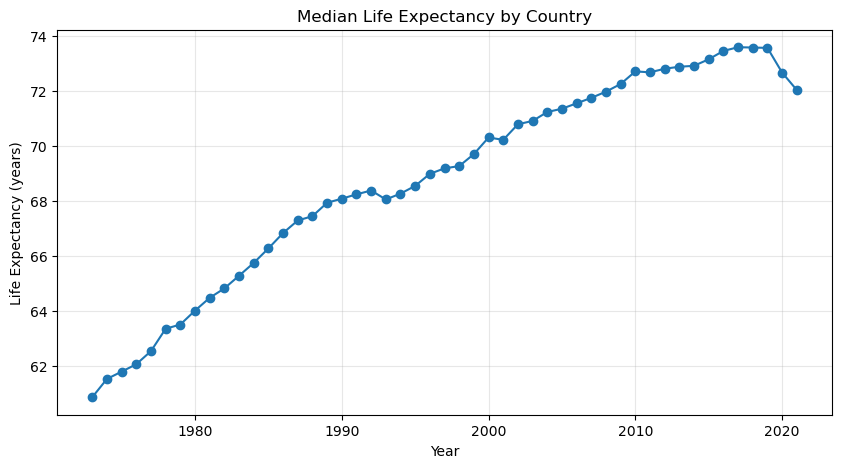

In [24]:
# Plot development trends
# Life expectancy
plt.figure(figsize=(10,5))

plt.plot(
    yearly.index,
    yearly["LifeExpBirth"],
    marker="o"
)
plt.title("Median Life Expectancy by Country")
plt.xlabel("Year")
plt.ylabel("Life Expectancy (years)")
plt.grid(True, alpha=0.3)

plt.show()

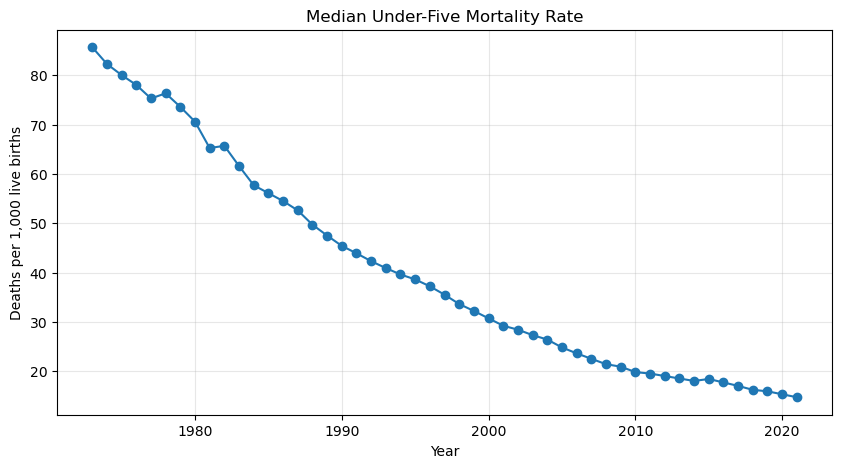

In [25]:
# Under-five mortality
plt.figure(figsize=(10, 5))

plt.plot(
    yearly.index,
    yearly["MortRateU5"],
    marker="o"
)

plt.title("Median Under-Five Mortality Rate")
plt.xlabel("Year")
plt.ylabel("Deaths per 1,000 live births")
plt.grid(True, alpha=0.3)

plt.show()

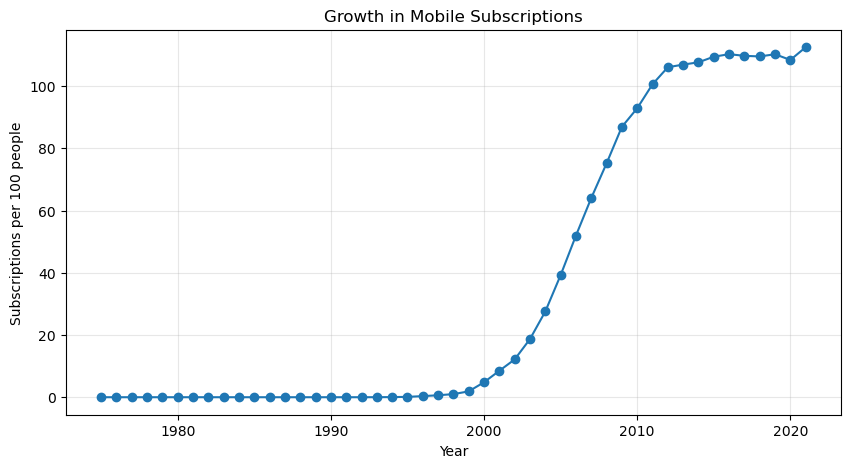

In [26]:
# Mobile subscriptions
plt.figure(figsize=(10, 5))

plt.plot(
    yearly.index,
    yearly["MobileSubs/100"],
    marker="o"
)

plt.title("Growth in Mobile Subscriptions")
plt.xlabel("Year")
plt.ylabel("Subscriptions per 100 people")
plt.grid(True, alpha=0.3)

plt.show()

In [27]:
# Calculate annual growth rates
annual_change = yearly.pct_change() * 100


display(
    annual_change.round(2)
)

,LifeExpBirth,MortRateU5,FertRate,GNI/CapAtlas,MobileSubs/100,AgriValAdd%GDP,GDPGrowth%
Year,,,,,,,
1973,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1974,1.09,-3.97,-2.34,42.31,NaN,-1.34,-7.99
1975,0.43,-2.73,-3.39,16.89,NaN,-3.32,-50.81
1976,0.44,-2.50,-2.33,-6.36,NaN,-10.96,126.08
1977,0.77,-3.52,-2.28,13.58,NaN,2.42,-10.87
1978,1.30,1.39,-2.62,9.78,NaN,-6.96,8.23
1979,0.24,-3.60,-2.04,26.73,NaN,-7.02,-15.18
1980,0.80,-4.08,1.82,6.64,NaN,-4.49,-21.68
1981,0.73,-7.58,-4.06,1.10,NaN,1.23,-5.76


In [28]:
largest_mobile_growth = annual_change[
    "MobileSubs/100"
].idxmax()
print(
    "Largest annual increase in mobile subscriptions:",
    largest_mobile_growth
)
print(
    "Growth rate:",
    round(
        annual_change.loc[
            largest_mobile_growth,
            "MobileSubs/100"
        ], 2
    ),
    "%"
)

Largest annual increase in mobile subscriptions: 1992
Growth rate: inf %


In [29]:
# Correlation analysis
correlation_variables = [
     "GDP",
    "GNI/CapAtlas",
    "LifeExpBirth",
    "MortRateU5",
    "FertRate",
    "MobileSubs/100",
    "AgriValAdd%GDP",
    "Exports%GDP",
    "Imports%GDP"
]
correlation_variables = [
    x for x in correlation_variables
    if x in df.columns
]
corr = df[correlation_variables].corr()
display(corr.round(2))

,GDP,GNI/CapAtlas,LifeExpBirth,MortRateU5,FertRate,MobileSubs/100,AgriValAdd%GDP,Exports%GDP,Imports%GDP
GDP,1.00,0.29,0.20,-0.15,-0.18,0.14,-0.15,-0.09,-0.15
GNI/CapAtlas,0.29,1.00,0.58,-0.43,-0.47,0.50,-0.49,0.37,0.16
LifeExpBirth,0.20,0.58,1.00,-0.93,-0.84,0.49,-0.73,0.35,0.21
MortRateU5,-0.15,-0.43,-0.93,1.00,0.84,-0.43,0.72,-0.33,-0.23
FertRate,-0.18,-0.47,-0.84,0.84,1.00,-0.46,0.68,-0.33,-0.20
MobileSubs/100,0.14,0.50,0.49,-0.43,-0.46,1.00,-0.44,0.30,0.21
AgriValAdd%GDP,-0.15,-0.49,-0.73,0.72,0.68,-0.44,1.00,-0.42,-0.22
Exports%GDP,-0.09,0.37,0.35,-0.33,-0.33,0.30,-0.42,1.00,0.79
Imports%GDP,-0.15,0.16,0.21,-0.23,-0.20,0.21,-0.22,0.79,1.00


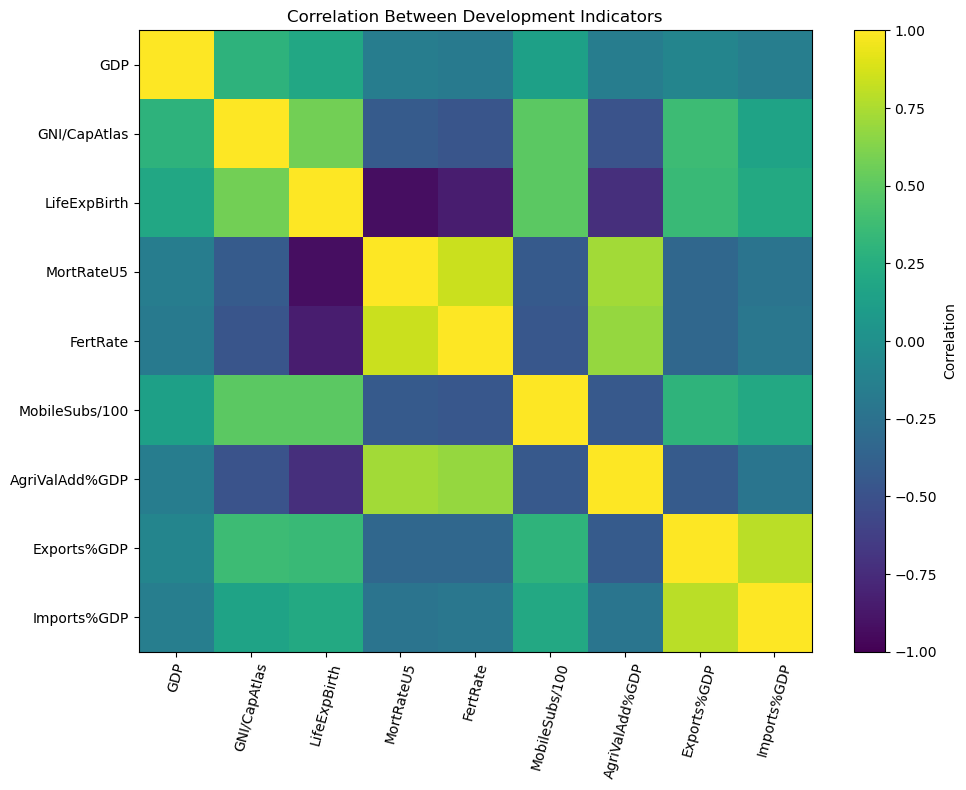

In [30]:
plt.figure(figsize=(10, 8))
plt.imshow(
    corr,
    aspect="auto",
    vmin=-1,
    vmax=1
)
plt.colorbar(label="Correlation")
plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=75
)
plt.yticks(
    range(len(corr.index)),
    corr.index
)
plt.title("Correlation Between Development Indicators")

plt.tight_layout()
plt.show()

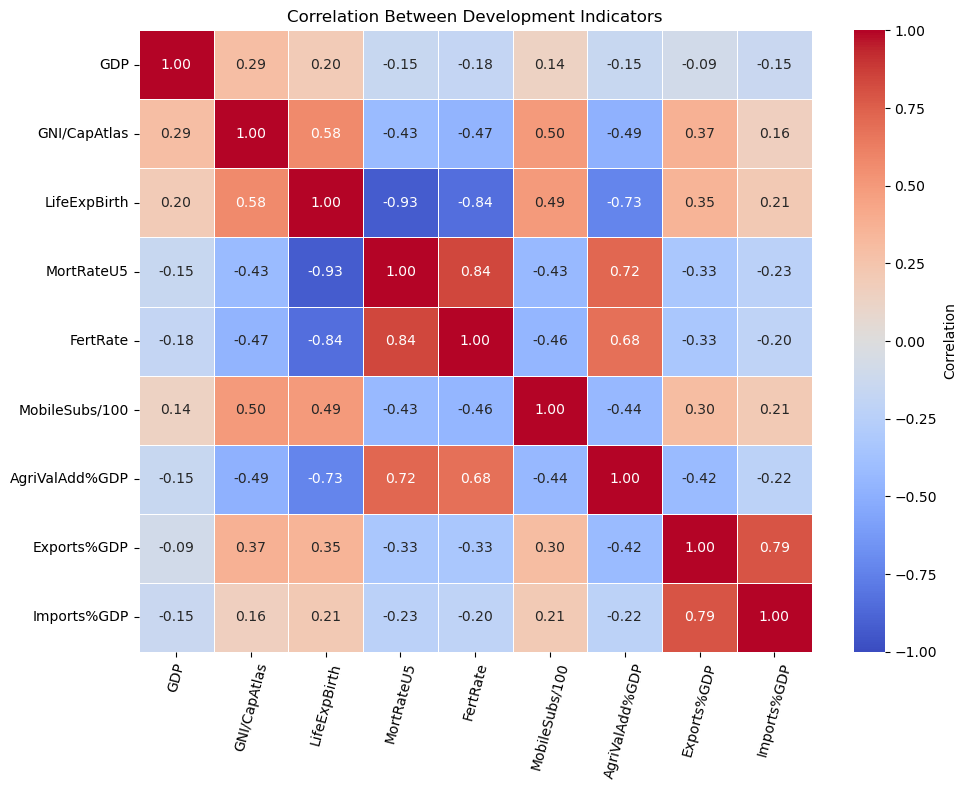

In [31]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    center=0,
    cmap="coolwarm",
    linewidths=0.5,
    cbar_kws={"label": "Correlation"}
)

plt.title("Correlation Between Development Indicators")
plt.xticks(rotation=75)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

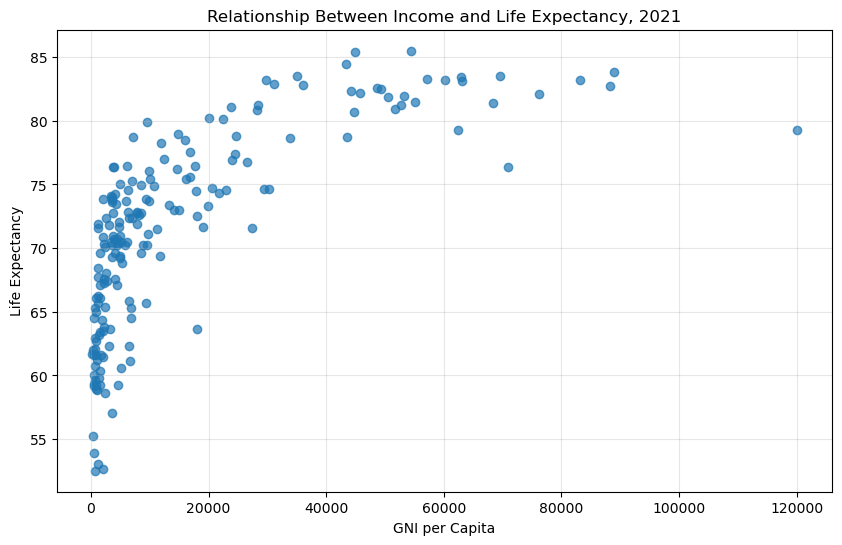

In [32]:
# GDP per capita and life expectancy relationship
data_2021 = df[df["Year"] == 2021].copy()

plt.figure(figsize=(10, 6))
plt.scatter(
    data_2021["GNI/CapAtlas"],
    data_2021["LifeExpBirth"],
    alpha=0.7
)
plt.xlabel("GNI per Capita")
plt.ylabel("Life Expectancy")
plt.title("Relationship Between Income and Life Expectancy, 2021")

plt.grid(True, alpha=0.3)
plt.show()

In [33]:
income_life_corr = data_2021[
    ["GNI/CapAtlas", "LifeExpBirth"]
].corr().iloc[0, 1]
print("Correlation between GNI per capita and life expectancy:", round(income_life_corr, 3)
)

Correlation between GNI per capita and life expectancy: 0.701


In [34]:
# GDP growth volatility
gdp_volatility = df.groupby("Country")["GDPGrowth%"].agg(
    Mean_GDP_Growth="mean",
    Median_GDP_Growth="median",
    GDP_Growth_Std="std",
    Maximum_Growth="max",
    Minimum_Growth="min"
)
display(gdp_volatility.sort_values(
    "GDP_Growth_Std",
    ascending=False
).head(20)
)

,Mean_GDP_Growth,Median_GDP_Growth,GDP_Growth_Std,Maximum_Growth,Minimum_Growth
Country,,,,,
Equatorial Guinea,13.345184,5.769421,27.737803,149.972963,-9.110041
Libya,3.065373,1.758611,26.107038,86.826748,-50.338515
Iraq,7.359885,4.722864,18.643135,57.817828,-64.047107
Nauru,6.733135,4.237288,18.209082,65.000000,-8.510638
Bosnia and Herzegovina,9.028263,3.897178,17.721796,88.957666,-3.015095
Lebanon,3.805011,3.227098,13.839544,49.447379,-42.451118
"Macao SAR, China",5.153053,6.464668,13.047497,26.630847,-54.235900
Maldives,5.873065,7.266758,12.672547,41.745101,-33.492796
Azerbaijan,3.980736,5.048945,12.531783,34.500000,-23.099999


In [35]:
# Identify high-development and low-development countries
development = df[df["Year"] == 2021].copy()

# Rank indicators
development["LifeExp_Rank"] = development["LifeExpBirth"].rank(ascending=False)
development["Mortality_Rank"] = development["MortRateU5"].rank(ascending=True)
development["Income_Rank"] = development["GNI/CapAtlas"].rank(ascending=False)
development["Fertility_Rank"] = development["FertRate"].rank(ascending=True)

# Overall descriptive index
development["Development_Index"] = (
    development["LifeExp_Rank"] +
    development["Mortality_Rank"] +
    development["Income_Rank"] +
    development["Fertility_Rank"]
)
display(
    development[
        [
            "Country",
            "LifeExpBirth",
            "MortRateU5",
            "GNI/CapAtlas",
            "FertRate",
            "Development_Index"
        ]
    ]
    .sort_values("Development_Index")
    .head(20)
)

,Country,LifeExpBirth,MortRateU5,GNI/CapAtlas,FertRate,Development_Index
9764,Singapore,83.441463,2.1,63000.0,1.120,27.0
9851,Japan,84.445610,2.3,43450.0,1.300,51.0
9848,Luxembourg,82.748780,2.7,88190.0,1.380,52.0
9823,"Korea, Rep.",83.526829,2.9,35110.0,0.808,54.0
9766,Norway,83.163415,2.2,83190.0,1.550,64.0
9938,Italy,82.795122,2.6,36130.0,1.250,65.5
9898,Spain,83.178049,3.0,29690.0,1.190,72.0
9772,Switzerland,83.851220,3.8,88910.0,1.520,74.5
9820,Finland,81.934146,2.2,53280.0,1.460,75.5
9769,Cyprus,81.203000,2.8,28470.0,1.321,92.0


In [36]:
# Agriculture versus economic development
agri_analysis = df[df["Year"] == 2021][[
    "Country",
    "Region",
    "AgriValAdd%GDP",
    "GNI/CapAtlas",
    "LifeExpBirth",
    "GDPGrowth%"
]].copy()
display(agri_analysis.corr(numeric_only=True).round(2)
)

,AgriValAdd%GDP,GNI/CapAtlas,LifeExpBirth,GDPGrowth%
AgriValAdd%GDP,1.00,-0.52,-0.67,-0.20
GNI/CapAtlas,-0.52,1.00,0.70,0.07
LifeExpBirth,-0.67,0.70,1.00,0.20
GDPGrowth%,-0.20,0.07,0.20,1.00


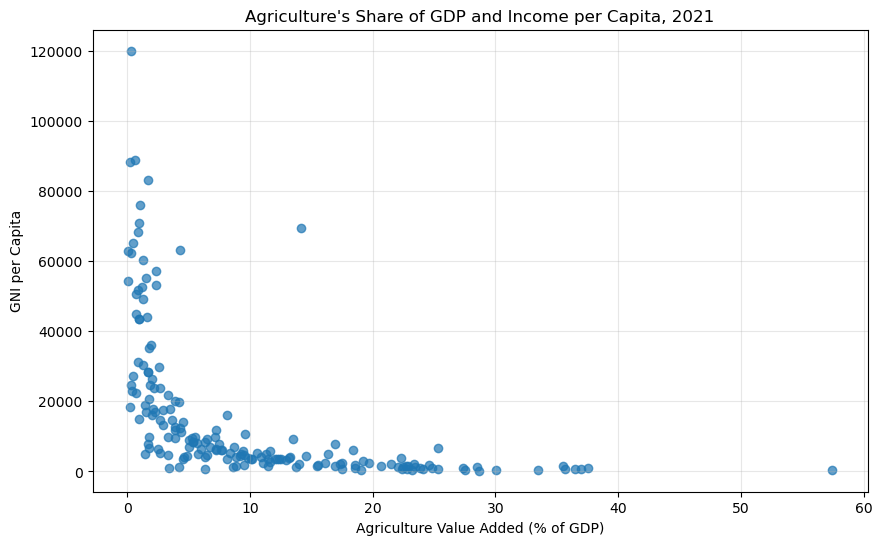

In [37]:
plt.figure(figsize=(10, 6))

plt.scatter(
    agri_analysis["AgriValAdd%GDP"],
    agri_analysis["GNI/CapAtlas"],
    alpha=0.7
)
plt.xlabel("Agriculture Value Added (% of GDP)")
plt.ylabel("GNI per Capita")
plt.title("Agriculture's Share of GDP and Income per Capita, 2021")

plt.grid(True, alpha=0.3)
plt.show()

In [38]:
# Measure inequality between regions
regional_2021 = df[df["Year"] == 2021].groupby("Region").agg({ 
    "LifeExpBirth": "median",
    "MortRateU5": "median",
    "GNI/CapAtlas": "median",
    "FertRate": "median",
    "MobileSubs/100": "median"
})
regional_gaps = pd.DataFrame({
    "Indicator": regional_2021.columns,
    "Maximum": regional_2021.max().values,
    "Minimum": regional_2021.min().values,
    "Regional Gap": (
        regional_2021.max().values -
        regional_2021.min().values
    )
})
display(regional_gaps.round(2))

,Indicator,Maximum,Minimum,Regional Gap
0,LifeExpBirth,80.70,61.66,19.04
1,MortRateU5,49.70,3.70,46.00
2,GNI/CapAtlas,25495.00,1545.00,23950.00
3,FertRate,4.09,1.57,2.52
4,MobileSubs/100,128.96,79.11,49.85


In [39]:
# Automatically generate a KPI summary for your report
report_kpis = []

indicators = {
    "Life expectancy": "LifeExpBirth",
    "Under-five mortality": "MortRateU5",
    "Fertility rate": "FertRate",
    "GNI per capita": "GNI/CapAtlas",
    "Mobile subscriptions": "MobileSubs/100",
    "Agriculture share of GDP": "AgriValAdd%GDP"
}
for name, column in indicators.items():
    start = df.loc[
        df["Year"] == 2000,
        column       
    ].median()


    absolute_change = end - start

    percentage_change = (
        absolute_change / abs(start)
    )*100

    if absolute_change > 0:
        direction = "INCREASE"
    elif absolute_change < 0:
        direction = "DECREASE"
    else:
        direction = "NO CHANGE"

    report_kpis.append({
        "KPI": name,
        "2000": round(start, 2),
        "2021": round(end, 2),
        "Absolute Change": round(absolute_change, 2),
        "% Change": round(percentage_change, 2),
        "Direction": direction
    })

report_kpis = pd.DataFrame(report_kpis)
display(report_kpis)



,KPI,2000,2021,Absolute Change,% Change,Direction
0,Life expectancy,70.31,79.11,8.79,12.51,INCREASE
1,Under-five mortality,30.70,79.11,48.41,157.68,INCREASE
2,Fertility rate,2.72,79.11,76.39,2812.71,INCREASE
3,GNI per capita,1930.00,79.11,-1850.89,-95.90,DECREASE
4,Mobile subscriptions,4.81,79.11,74.30,1543.86,INCREASE
5,Agriculture share of GDP,9.25,79.11,69.86,755.34,INCREASE


"""
The data analysis demonstrate substantial changes in economic, demographic, social and structural development. The KPIs show that between 2000 and 2021, median life expectancy increased from about 70.09 to 71.98 years (+1.89 years), while under-five mortality decreased from 30.55 to 16.45 deaths per 1,000 live births (−46.2%) and the fertility rate declined from 2.72 to 2.09 births per woman (−23.3%), demonstrating improvements in child survival and a transition toward lower fertility. Mobile subscriptions increased from 5.28 to 112.20 per 100 people (+2,023.9%), indicating a very substantial expansion in digital connectivity, while agriculture's share of GDP decreased from 8.43% to 5.70% (−32.4%), demonstrating a shift in the economic structure toward other sectors rather than necessarily a decline in agricultural output. The analysis also identified a positive relationship between GNI per capita and life expectancy, while the correlation analysis showed an inverse relationship between life expectancy and both under-five mortality and fertility, indicating that countries with higher income levels tended to record better selected social-development outcomes. Regional analysis further demonstrated persistent differences in development outcomes, meaning that progress was not uniform across regions. Therefore, the analysis recommends that development planning should focus on sustaining gains in life expectancy and child survival, expanding digital connectivity, improving income-generating opportunities and addressing regional disparities, while simultaneously supporting productive agricultural transformation as agriculture's relative contribution to GDP declines.
"""